# Plateau’s Problem (or minimal surface problem)

### Imports and setup

In [1]:
import os, sys
sys.path.append(os.path.abspath(os.path.join(os.curdir, '..')))

import torch
import numpy as np
from tqdm.notebook import trange
import k3d
import matplotlib.pyplot as plt

device = 'cuda'
torch.set_default_device(device)

### Define the boundary rectangles

In [3]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    bndry = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return bndry

pts_bndry = get_boundary_angled_rectangles()
pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

bounds = torch.vstack([pts_bndry.min(0).values, pts_bndry.max(0).values]).T

## Plot
fig = k3d.plot()
fig += k3d.points(pts_bndry.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

In [4]:
from models.NN import GeneralNet
model = GeneralNet(ks=[3, 32, 32, 1])

# from models.wire import WIRE ## TODO: requires the model
# model = WIRE(layers=[3, 64, 64, 1]) ## TODO: w0_initial: 18, wire_scale: 6

In [5]:
## TODO: use netp

## Define the functional expressions
from torch.func import vmap, jacrev, jacfwd, functional_call

params = dict(model.named_parameters())
def f(params, x):
    return functional_call(model, params, x)


## Jacobian of f with respect to the input x
f_x = jacrev(f, argnums=1)  ## params, [nx] -> [ny, nx]
vf_x = vmap(f_x, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx]
## Hessian of f with respect to the input x
f_xx = jacfwd(f_x, argnums=1)  ## params, [nx] -> [ny, nx, nx]
vf_xx = vmap(f_xx, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx, nx]
# Laplacian of f with respect to the input x
def laplacian_f(params, x):
    hessian = f_xx(params, x).squeeze(1)  # Compute the Hessian
    laplacian = torch.einsum('bii->b', hessian)  # Sum of the diagonal elements to get the Laplacian
    return laplacian
v_laplacian_f = vmap(laplacian_f, in_dims=(None, 0), out_dims=(0))
## Phi (Gradients of f wrt theta)
f_theta = jacrev(f, argnums=0)  # dict
vf_theta = vmap(f_theta, in_dims=(None, 0), out_dims=(0))
## Laplacian of Phi
laplacian_phi = jacrev(laplacian_f, argnums=0) # dict
v_laplacian_phi = vmap(laplacian_phi, in_dims=(None, 0), out_dims=(0))

### Define mean curvature function

In [6]:
## TODO: import from main codebase

# def get_mean_curvature(F, H):
#     '''
#     Mean-curvature in D-dimensions
#     F: grad(f) gradients, shape [N,D]
#     H: hess(f) Hessian, shape [N,D,D]

#     https://u.math.biu.ac.il/~katzmik/goldman05.pdf
#     For a shape implicitly defined by f<0:
#     - div(F/|F|) = -(FHF^T - |F|^2 tr(H)) / 2*|F|^3
#     In <=3D we can expand the formula, if we want to validate https://www.archives-ouvertes.fr/hal-01486547/document
#     fx, fy, fz = F.T
#     fxx, fxy, fxz, fyx, fyy, fyz, fzx, fzy, fzz = H.flatten(start_dim=1).T
#     k = (fx*fx*(fyy+fzz) + fy*fy*(fxx+fzz) + fz*fz*(fxx+fyy) - 2*(fx*fy*fxy+fx*fz*fxz+fy*fz*fyz)) / (2*(fx*fx+fy*fy+fz*fz).pow(3/2))
#     '''
#     ## Quadratic form
#     FHFT = torch.einsum('bi,bij,bj->b', F, H, F)
#     ## Trace of Hessian
#     trH = torch.einsum('bii->b', H)
#     ## Norm of gradient
#     N = F.square().sum(1).sqrt()
#     ## Mean-curvature
#     mean_curvatures = -(FHFT - N.pow(2)*trH) / (2*N.pow(3))
#     return mean_curvatures

# def get_laplacians(H):
#     '''Compute the Laplacian only. This can be used with the eikonal constraint.'''
#     return torch.einsum('bii->b', H)

### Main training loop

In [7]:
## TODO: merge into main codebase, import

def adaptive_penalty_update(mu_dict: dict, lambda_dict: dict, nu_dict: dict, sub_loss_unweighted_dict: dict) -> dict:
    gamma = 0.01
    alpha = 0.9
    epsilon = 1.e-08

    with torch.no_grad():
        for key in sub_loss_unweighted_dict.keys():
            nu_dict[key] = nu_dict[key] * alpha + (1-alpha) * sub_loss_unweighted_dict[key]
            mu_dict[key] = gamma / (torch.sqrt(nu_dict[key]) + epsilon)
            lambda_dict[key] = lambda_dict[key] + mu_dict[key] * torch.sqrt(sub_loss_unweighted_dict[key])

    return mu_dict, lambda_dict, nu_dict

In [13]:
# Approximate Hessians

def calculate_A_interface(vf_theta, params, pts_bndry):
    """
    Calculate the boundary integral matrix A_bndry.
    
    Args:
        vf_theta: Function mapping parameters and points to derivatives (jacobian).
        params: Model parameters as a dictionary.
        pts_bndry: Boundary points as a tensor of shape [n_points, n_dims].
        interface_length: Length of the interface for scaling (default: 8).
        
    Returns:
        torch.Tensor: Approximate Hessian of the boundary loss [n_params, n_params].
    """
    # Compute φ_i at boundary points
    phi_at_pts = vf_theta(params, pts_bndry)  # Returns a dict

    # Aggregate φ_i into a single tensor
    phi_at_pts_tensor = torch.cat([p.flatten(start_dim=1) for p in phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_bndry = torch.einsum('bi,bj->ij', phi_at_pts_tensor, phi_at_pts_tensor) / len(pts_bndry)

    return A_bndry

def calculate_A_laplacian(v_laplacian_phi, params, pts):
    """
    Calculate the Laplacian integral matrix A_laplacian.
    
    Args:
        vf_theta_lap: Function mapping parameters and points to Laplacians (second derivatives).
        params: Model parameters as a dictionary.
        pts: Surface points as a tensor of shape [n_points, n_dims].
        
    Returns:
        torch.Tensor: Approximate Hessian of the laplacian loss [n_params, n_params].
    """
    
    # Compute Laplacians of φ_i at points
    lap_phi_at_pts = v_laplacian_phi(params, pts)  # Returns a dict
    
    # Aggregate Laplacians into a single tensor
    lap_phi_tensor = torch.cat([p.flatten(start_dim=1) for p in lap_phi_at_pts.values()], dim=1)  # Shape: [n_points, n_params]
    A_laplacian = torch.einsum('bi,bj->ij', lap_phi_tensor, lap_phi_tensor) / len(pts_bndry)

    return A_laplacian

  0%|          | 0/10000 [00:00<?, ?it/s]

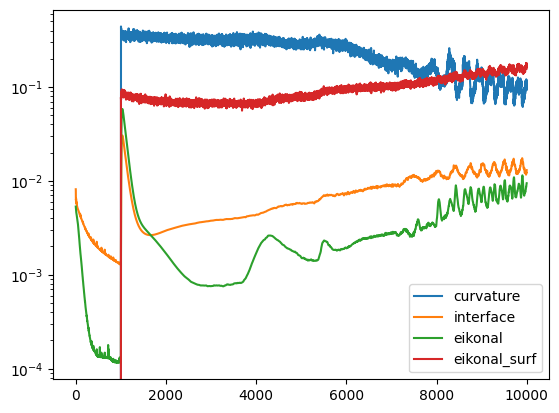

In [31]:
## Losses
constraint_keys = ['curvature', 'interface', 'eikonal', 'eikonal_surf']
objective_keys = []
## NOTE: if you don't want to use ALM, specify all losses as objectives
# constraint_keys = []
# objective_keys = ['interface', 'eikonal', 'curvature', 'eikonal_surf']
loss_keys = constraint_keys + objective_keys

losses = {key: torch.zeros(1) for key in loss_keys}

## Logging
loss_over_iters = {key: {} for key in loss_keys}


if reinit:=1: ## Reinitialize optimizer and ALM?
    ## Optimizer
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)

    ## ALM
    mu_dict = {key: torch.tensor(.1) for key in constraint_keys}
    nu_dict = {key: torch.tensor(0.) for key in constraint_keys}
    lambda_dict = {key: torch.tensor(.1) for key in constraint_keys}


## Train
for i in (pbar := trange(10000)):
    opt.zero_grad()
    
    ## INTERFACE ##
    ## f should be 0 on the boundary points pts_bndry
    loss_interface  = f(params, pts_bndry).square().mean()
    loss_interface += 10*f(params, pts_corners).square().mean()
    losses['interface'] = loss_interface
    
    ## EIKONAL ##
    ## Eikonal should satisfied at boundary points pts_bndry (can also enforce everywhere)
    # pts = 1.2*torch.rand([10000, 3]) - 0.1
    # loss_eikonal  = (vf_x(params, pts).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal  = (vf_x(params, pts_bndry).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    losses['eikonal'] = loss_eikonal
    
    ## CURVATURE ##
    ## Reset losses
    losses['eikonal_surf'] = torch.tensor(0)
    losses['curvature'] = torch.tensor(0)
    
    if i>1000:
        ## Sample points on surface TODO: newton iters, reuse prev pts, maybe repel
        with torch.no_grad():
            pts = torch.rand([10000, 3])
            vals_sq = model(pts).square().squeeze()
            pts = pts[vals_sq<1e-4]
        ## The surface should have 0 mean-curvature
        if len(pts):
            Fs = vf_x(params, pts).squeeze(1)
            # Hs = vf_xx(params, pts).squeeze(1)
            if use_laplacian:=1:
                mean_curvatures = v_laplacian_f(params, pts).squeeze(1)
                losses['eikonal_surf'] = (Fs.square().sum(1).sqrt() - 1).square().mean() ## enforce eikonal on the surface
            else:
                mean_curvatures = get_mean_curvature(Fs, Hs)
            losses['curvature'] = mean_curvatures.square().mean()


    loss = 0
    ## Add constraint violations
    for key in constraint_keys:
        # print(key, losses[key])
        loss += lambda_dict[key]*losses[key] + .5*mu_dict[key]*losses[key].square()
    ## Add objective(s)    
    for key in objective_keys:
        # print(key, losses[key])
        loss += losses[key] ## TODO: with multiplier if multiple objectives?
    
    loss.backward()
    opt.step()

    ## ALM
    sub_loss_unweighted_dict = {key: losses[key].detach() for key in constraint_keys} ## TODO: this can be simplified. Just pass losses?
    mu_dict, lambda_dict, nu_dict = adaptive_penalty_update(mu_dict, lambda_dict, nu_dict, sub_loss_unweighted_dict)

    ## Log the individual losses for plotting
    for key in loss_keys:
        loss_over_iters[key][i] = losses[key].item()

    ## Log the losses in progress-bar
    desc = ''
    for key in loss_keys:
        desc += f"{key}: {losses[key].item():.2e} \t"
    pbar.set_description(desc)


for loss_key in loss_keys:
    plt.plot(list(loss_over_iters[loss_key].keys()), list(loss_over_iters[loss_key].values()), label=loss_key)
plt.semilogy()
plt.legend()
plt.show()

### Visualize the surface

In [32]:
from util.visualization.utils_mesh import get_mesh
verts, faces = get_mesh(model, N=64, device=device, bbox_min=bounds[:,0]-.1, bbox_max=bounds[:,1]+.1, chunks=1)

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=0xbbbbbb, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig.display()

c:\Users\james\Desktop\Studium ETH\Master Thesis\GINN Code\ginn_env\lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [ ]:
# Define the boundary loss function
def boundary_loss(params, pts_bndry):
    return f(params, pts_bndry).square().mean()

def flatten_hessian(hessian_dict):
    flattened_hessian = []
    for key1 in sorted(hessian_dict.keys()):
        for key2 in sorted(hessian_dict[key1].keys()):
            flattened_hessian.append(hessian_dict[key1][key2].flatten(start_dim=1))
    return torch.cat(flattened_hessian)

## Losses
constraint_keys = ['curvature', 'interface', 'eikonal', 'eikonal_surf']
objective_keys = []
## NOTE: if you don't want to use ALM, specify all losses as objectives
# constraint_keys = []
# objective_keys = ['interface', 'eikonal', 'curvature', 'eikonal_surf']
loss_keys = constraint_keys + objective_keys

losses = {key: torch.zeros(1) for key in loss_keys}

## Logging
loss_over_iters = {key: {} for key in loss_keys}


if reinit:=1: ## Reinitialize optimizer and ALM?
    ## Optimizer
    opt = torch.optim.Adam(model.parameters(), lr=3e-4)

    ## ALM
    mu_dict = {key: torch.tensor(.1) for key in constraint_keys}
    nu_dict = {key: torch.tensor(0.) for key in constraint_keys}
    lambda_dict = {key: torch.tensor(.1) for key in constraint_keys}


## Train
for i in (pbar := trange(10000)):
    opt.zero_grad()
    
    ## INTERFACE ##
    ## f should be 0 on the boundary points pts_bndry
    loss_interface  = f(params, pts_bndry).square().mean()
    loss_interface += 10*f(params, pts_corners).square().mean()
    losses['interface'] = loss_interface
    
    ## EIKONAL ##
    ## Eikonal should satisfied at boundary points pts_bndry (can also enforce everywhere)
    # pts = 1.2*torch.rand([10000, 3]) - 0.1
    # loss_eikonal  = (vf_x(params, pts).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal  = (vf_x(params, pts_bndry).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    losses['eikonal'] = loss_eikonal
    
    ## CURVATURE ##
    ## Reset losses
    losses['eikonal_surf'] = torch.tensor(0)
    losses['curvature'] = torch.tensor(0)
    
    if i>1000:
        ## Sample points on surface TODO: newton iters, reuse prev pts, maybe repel
        with torch.no_grad():
            pts = torch.rand([10000, 3])
            vals_sq = model(pts).square().squeeze()
            pts = pts[vals_sq<1e-4]
        ## The surface should have 0 mean-curvature
        if len(pts):
            Fs = vf_x(params, pts).squeeze(1)
            # Hs = vf_xx(params, pts).squeeze(1)
            if use_laplacian:=1:
                mean_curvatures = v_laplacian_f(params, pts).squeeze(1)
                losses['eikonal_surf'] = (Fs.square().sum(1).sqrt() - 1).square().mean() ## enforce eikonal on the surface
            else:
                mean_curvatures = get_mean_curvature(Fs, Hs)
            losses['curvature'] = mean_curvatures.square().mean()


    loss = 0
    ## Add constraint violations
    for key in constraint_keys:
        # print(key, losses[key])
        loss += lambda_dict[key]*losses[key] + .5*mu_dict[key]*losses[key].square()
    ## Add objective(s)    
    for key in objective_keys:
        # print(key, losses[key])
        loss += losses[key] ## TODO: with multiplier if multiple objectives?
    
    loss.backward()
    opt.step()

    ## ALM
    sub_loss_unweighted_dict = {key: losses[key].detach() for key in constraint_keys} ## TODO: this can be simplified. Just pass losses?
    mu_dict, lambda_dict, nu_dict = adaptive_penalty_update(mu_dict, lambda_dict, nu_dict, sub_loss_unweighted_dict)

    ## Log the individual losses for plotting
    for key in loss_keys:
        loss_over_iters[key][i] = losses[key].item()

    ## Log the losses in progress-bar
    desc = ''
    for key in loss_keys:
        desc += f"{key}: {losses[key].item():.2e} \t"
    pbar.set_description(desc)

    if i % 500 == 0:
        # Calculate the approximate Hessian A_bndry
        A_interface = calculate_A_interface(vf_theta, params, pts_bndry)
        
        gradient_boundary_loss = jacrev(boundary_loss, argnums=0)
        hessian_boundary_loss = jacfwd(gradient_boundary_loss, argnums=0)
        print(hessian_boundary_loss(params, pts_bndry))

        hessian_boundary_loss_tensor = flatten_hessian(hessian_boundary_loss(params, pts_bndry)) # The Flattening is still wrong
        
        
        frobenius_norm_diff = torch.norm(hessian_boundary_loss_tensor - A_interface, p='fro')
        print(f"Step {i}: Frobenius norm of the difference: {frobenius_norm_diff.item()}")


for loss_key in loss_keys:
    plt.plot(list(loss_over_iters[loss_key].keys()), list(loss_over_iters[loss_key].values()), label=loss_key)
plt.semilogy()
plt.legend()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 150.00 MiB (GPU 0; 2.00 GiB total capacity; 5.08 GiB already allocated; 0 bytes free; 5.25 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF